#Gabrielle Johnson's Week 6 Interim Deliverable


##Importing Libraries 📚

In [20]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: loads the Python "tools" (libraries) we need.
#   - pandas: works with tables of data (like a spreadsheet in code)
#   - matplotlib: draws charts
#   - scikit-learn (sklearn): the machine-learning toolkit
#   - joblib: saves a trained model to a file so we can reuse it later
# You only run this once at the top of the notebook.
# ------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
#os.makedirs("figs", exist_ok=True)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from pathlib import Path
from google.colab import drive

pd.set_option("display.width", 120)
print("Libraries loaded. ✅")

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score, recall_score,
)

Libraries loaded. ✅


## Setting up the Environment ⚙

In [21]:
# mount Drive
drive.mount("/content/drive")
DATA_PATH = Path("/content/drive/MyDrive/yaleemmlc_admissionprediction_triage.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find {DATA_PATH}. Place the CSV beside this notebook, or set DATA_PATH (Colab).")

# index_col=0 drops the unnamed export row-number column
df = pd.read_csv(DATA_PATH, index_col=0)
print(f"Loaded {df.shape[0]:,} ED encounters  x  {df.shape[1]} columns")

#inspecting the data
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 55,121 ED encounters  x  225 columns


,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Categorise Columns 🔗

In [22]:
TARGET = "esi"

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
# Who the patient is (some of these are fairness-sensitive — handle with care):
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
# OUTCOMES of the visit — known only AFTER triage, so they must never be model inputs:
LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]

chief_complaints = [col for col in df.columns if col.startswith("cc_")]

In [23]:
# Reference ranges for general adult triage since there are no paediatric patients. Each entry is (low, high, unit).
NORMAL_RANGES = {"triage_vital_hr": (60,100,"bpm"), "triage_vital_sbp": (90,140,"mmHg"),
    "triage_vital_dbp": (60,90,"mmHg"), "triage_vital_rr": (12,20,"/min"),
    "triage_vital_o2": (95,100,"%"), "triage_vital_temp": (97.0,99.5,"F"), "triage_glucose": (70,140,"mg/dL")}

# "Plausible" bounds are much wider than normal — anything OUTSIDE these is treated as a
# data error (e.g. a heart rate of 5). Each entry is (low, high).
PLAUSIBLE = {"age": (0,120), "esi": (1,5), "triage_vital_hr": (20,250), "triage_vital_sbp": (50,300),
    "triage_vital_dbp": (20,200), "triage_vital_rr": (4,60), "triage_vital_o2": (50,100),
    "triage_vital_temp": (86,110), "triage_glucose": (20,800)}

##Cleaning the Dataset 🧼

In [24]:
def clean_triage(raw):
    """
    Takes the raw DataFrame and returns a cleaned copy.
    """
    d = raw.copy()

    # Drop rows with no esi
    d = d[d[TARGET].notna()].copy()

    # Convert expected numeric fields to numeric
    numeric_cols = [c for c in VITALS if c in d.columns]
    if "age" in d.columns:
        numeric_cols.append("age")
    numeric_cols.append(TARGET)

    for col in numeric_cols:
        d[col] = pd.to_numeric(d[col], errors="coerce")

    # Drop rows where ESI became invalid after numeric conversion
    d = d[d[TARGET].notna()].copy()

    # Add impossible value flags only if implausible values exist
    for col, (low, high) in PLAUSIBLE.items():
        if col in d.columns:
            out_of_range = (d[col] < low) | (d[col] > high)
            if out_of_range.any():
                d[f"{col}_was_impossible"] = out_of_range.astype(int)

    # Add missingness flags only for vitals that have missing values
    for col in VITALS:
        if col in d.columns and d[col].isna().sum() > 0:
            d[f"{col}_was_missing"] = d[col].isna().astype(int)
            d[col] = d[col].fillna(d[col].median())

    # Oxygen device flag: blank means no device recorded
    if "triage_vital_o2_device" in d.columns:
        d["triage_vital_o2_device"] = (
            pd.to_numeric(d["triage_vital_o2_device"], errors="coerce").fillna(0)
        )

    # Clean chief complaint flags
    for col in chief_complaints:
        d[col] = pd.to_numeric(d[col], errors="coerce").fillna(0)
        d[col] = (d[col] == 1).astype(int)

    # Clean categorical text columns
    for col in DEMOGRAPHICS + ADMIN + LEAKAGE:
        if col in d.columns and d[col].dtype == object:
            d[col] = (
                d[col].astype(str).str.strip()
                .replace({"": "Unknown", "nan": "Unknown", "NaN": "Unknown",
                          "None": "Unknown", "NONE": "Unknown"})
                .fillna("Unknown")
            )

    # Convert target to integer
    d[TARGET] = d[TARGET].round().astype(int)

    return d

In [25]:
df=clean_triage(df)
df.head()

,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,...,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain,triage_vital_rr_was_impossible,triage_glucose_was_impossible
7,A,4,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,...,0,0,0,0,0,0,0,0,0,0
17,B,2,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,...,0,0,0,0,0,0,0,0,0,0
40,A,2,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,...,1,0,0,0,0,0,0,0,0,0
47,A,3,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,...,0,0,0,0,0,0,0,0,0,0
60,A,2,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,...,0,0,0,0,0,0,0,0,0,0


##Choosing the Features (X) and the Target (y)

In [26]:
X = df[FEATURES]     #the clues the model may use to make that prediction
y = df[TARGET]       #the thing we want to PREDICT  -> esi (the triage level 1-5)

print("Model will use", len(FEATURES), "features to predict:", TARGET)
print("First few features:", FEATURES[:10], "...")

Model will use 208 features to predict: esi
First few features: ['triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2', 'triage_vital_o2_device', 'triage_vital_temp', 'triage_glucose', 'cc_abdominalcramping', 'cc_abdominaldistention'] ...


##Split into training and test sets 🏋
> Uses random_state= 42

In [27]:
#separates a TEST set (20%) that the model will not see during training, so later we can grade it honestly.
#stratify=y keeps the ESI mix balanced across both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Training patients:", X_train.shape[0])
print("Testing patients: ", X_test.shape[0])

Training patients: 44096
Testing patients:  11025


## A baseline to beat (DummyClassifier) 🥊

In [28]:
#prediction based only on the class distribution, not on the features
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train)
print(f"Dummy baseline accuracy: {dummy.score(X_test, y_test):.2f}")

Dummy baseline accuracy: 0.38


##Logistic Regression 🧠♻






In [29]:
# scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# train the model
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
print(f"Scaled logistic regression test accuracy: {logreg.score(X_test_scaled, y_test):.3f}")



Scaled logistic regression test accuracy: 0.667


## Predictions on the Test Set

In [30]:
#get the predicted ESI for the test set.
pred_logreg =logreg.predict(X_test_scaled)
print("Example predictions (logreg):", pred_logreg[:10])

Example predictions (logreg): [2 3 3 2 2 2 3 3 3 2]


## Confusion Matrix 🔍

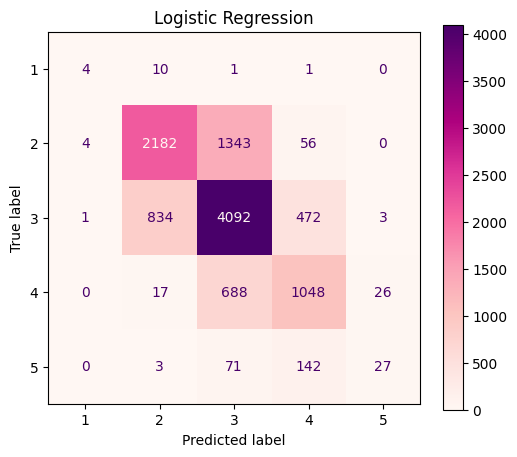

In [32]:
#confusion matrix
# Rows = true ESI, columns = predicted ESI. Diagonal = correct.
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg, ax=ax, cmap="RdPu")
ax.set_title("Logistic Regression")
fig.savefig("/content/drive/MyDrive/confusion_matrix_logreg.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Accuracy, Precision, Recall, F1, Classification Report 📊📝




In [33]:
#weighted f1 score- weighted by class size
f1_weighted=f1_score(y_test, pred_logreg, average='weighted')
print(f"F1_Score Weighted: {f1_weighted:.3f}")

#macro f1 score - every class counts equally
f1_macro=f1_score(y_test, pred_logreg, average='macro')
print(f"\nF1_ Score Macro: {f1_macro:.3f}")

#specifically looking at the recall for esi 1
recall=recall_score(y_test, pred_logreg, labels=[1], average=None)[0]
print(f"\nRecall for ESI 1: {recall:.3f}")

#Classification report
print(f"\nClassification report:\n{classification_report(y_test, pred_logreg)}")

F1_Score Weighted: 0.661

F1_ Score Macro: 0.493

Recall for ESI 1: 0.250

Classification report:
              precision    recall  f1-score   support

           1       0.44      0.25      0.32        16
           2       0.72      0.61      0.66      3585
           3       0.66      0.76      0.71      5402
           4       0.61      0.59      0.60      1779
           5       0.48      0.11      0.18       243

    accuracy                           0.67     11025
   macro avg       0.58      0.46      0.49     11025
weighted avg       0.67      0.67      0.66     11025



##Saving Trained Model 🤖

In [34]:
save_model = Path("/content/drive/MyDrive/trained_models")
save_model.mkdir(exist_ok=True)

joblib.dump(logreg, save_model / "model_logreg.joblib")
joblib.dump(scaler, save_model / "scaler.joblib")
print("Saved to Drive ✅")

Saved to Drive ✅
